# Downloads images from instagram of a particular username, and classifies images as human or non-human

In [92]:
import tensorflow as tf
import os
import random
from shutil import copyfile

from PIL import Image
from numpy import asarray
from keras.preprocessing import image
from keras.preprocessing.image import ImageDataGenerator
from IPython.display import Image, display
import h5py
import numpy as np
from keras.preprocessing import image
import matplotlib.pyplot as plt

## Creating directories of train and test, and splitting the photos randomly into 90% and 10% into train and test directories

In [4]:
dir_list = os.listdir('A:/python_data/Instagram Classifier/data orig')
    

try:
    os.mkdir('A:/python_data/Instagram Classifier/data formatted/train')
    os.mkdir('A:/python_data/Instagram Classifier/data formatted/test')
    
except:
    print('Train and Test directories already created')
    
for item in dir_list:
    try:
        os.mkdir('A:/python_data/Instagram Classifier/data formatted/train/' + item)
        os.mkdir('A:/python_data/Instagram Classifier/data formatted/test/' + item)
    except:
        print('all necessary directories already created')
        
SOURCE = 'A:/python_data/Instagram Classifier/data orig/'


for item in dir_list:
    #creating list of all images in each directory
    dir_image_list = os.listdir(SOURCE + item + '/')
    #we will append image file paths of all the images which are readable and are greater than 4kb
    proper_images_list = []
    
    #going through the list of all images in the directory
    for image in dir_image_list:
        file_path = SOURCE + item + '/' + image
        
        #size of image should be greater than 4 kb
        if os.path.getsize(file_path)/1024 > 4:
            proper_images_list.append(image)
        else:
            continue
        
    length = len(proper_images_list)
    
    #splitting training and testing set into 90% and 10%
    split_point = int(length *0.9)
    
    #shuffling the list
    shuffled = random.sample(proper_images_list, length)
    
    train_proper_images_list = shuffled[:split_point]
    test_proper_images_list = shuffled[split_point:]
    
    TRAINING = 'A:/python_data/Instagram Classifier/data formatted/train/' + item + '/'
    TESTING = 'A:/python_data/Instagram Classifier/data formatted/test/' + item + '/'
    
    for file_name in train_proper_images_list:
        try:
            #this is a check of whether the system can read the image
            #some images even though windows explorer opens them, tensorflow doesn't like it
            #if the follwing line of code work, then there is no issue with the image
            byteImg = Image.open(file_directory)
            
            copyfile(SOURCE + item + '/' + file_name , TRAINING + file_name)
            
        except:
            continue
    
    for file_name in test_proper_images_list:
        try:
            copyfile(SOURCE + item + '/' + file_name , TESTING + file_name)
        except:
            continue
    
    print('training and testing directories created and images added for ', item)
    


Train and Test directories already created
all necessary directories already created
all necessary directories already created
training and testing directories creates, and images added for  Cat
training and testing directories creates, and images added for  Dog
training and testing directories creates, and images added for  Human
training and testing directories creates, and images added for  Not Human


## Creating Tensorflow Model

In [89]:
model = tf.keras.models.Sequential([
    tf.keras.layers.Conv2D(16, (3,3), activation = 'relu', input_shape = (300, 300,3)),
    tf.keras.layers.MaxPooling2D(2,2),
    
    tf.keras.layers.Conv2D(32, (3,3),  activation='relu'),
    tf.keras.layers.MaxPooling2D(2,2),
    
    tf.keras.layers.Conv2D(64, (3,3),  activation='relu'),
    tf.keras.layers.MaxPooling2D(2,2),
    
    tf.keras.layers.Conv2D(64, (3,3),  activation='relu'),
    tf.keras.layers.MaxPooling2D(2,2),
    
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(512, activation = 'relu'),
    tf.keras.layers.Dense(2, activation = 'softmax')
])

model.compile(loss = 'categorical_crossentropy', 
             optimizer = 'adam', 
             metrics= 'accuracy')

#normalizing data
train_datagen = ImageDataGenerator(
    rescale = 1/255,
    rotation_range = 40,
    width_shift_range = 0.2,
    shear_range = 0.2,
    zoom_range =0.2,
    horizontal_flip = True,
    fill_mode = 'nearest'
)

train_generator = train_datagen.flow_from_directory(
    'A:/python_data/Instagram Classifier/data formatted/train/',
    target_size = (300,300),
    batch_size = 100,
    class_mode = "categorical"
)


validation_datagen = ImageDataGenerator(
    rescale=1 / 255,
)


validation_generator = validation_datagen.flow_from_directory(
    'A:/python_data/Instagram Classifier/data formatted/train/',
    batch_size=100,
    class_mode='categorical',
    target_size=(300, 300)
)

# model.summary()

Found 2122 images belonging to 2 classes.
Found 2122 images belonging to 2 classes.


In [90]:
try:
    final_model = tf.keras.models.load_model('my_model3.h5')
    
except:
    final_model  = model.fit(
    train_generator,
    steps_per_epoch =22,
    epochs = 7,
    verbose = 1,
    validation_data=validation_generator)
    model.save('my_model4.h5')



Epoch 1/7
22/22 [==============================] - 265s 12s/step - loss: 0.7746 - accuracy: 0.6310 - val_loss: 0.4573 - val_accuracy: 0.8021
Epoch 2/7
22/22 [==============================] - 264s 12s/step - loss: 0.5011 - accuracy: 0.7601 - val_loss: 0.4146 - val_accuracy: 0.8162
Epoch 3/7
22/22 [==============================] - 251s 11s/step - loss: 0.4674 - accuracy: 0.7714 - val_loss: 0.3537 - val_accuracy: 0.8577
Epoch 4/7
22/22 [==============================] - 257s 12s/step - loss: 0.4262 - accuracy: 0.8115 - val_loss: 0.3509 - val_accuracy: 0.8582
Epoch 5/7
22/22 [==============================] - 257s 12s/step - loss: 0.3897 - accuracy: 0.8252 - val_loss: 0.3230 - val_accuracy: 0.8732
Epoch 6/7
22/22 [==============================] - 255s 12s/step - loss: 0.3304 - accuracy: 0.8572 - val_loss: 0.2427 - val_accuracy: 0.8987
Epoch 7/7
22/22 [==============================] - 270s 12s/step - loss: 0.3364 - accuracy: 0.8534 - val_loss: 0.2155 - val_accuracy: 0.9128


### defining predictor function

In [83]:
from keras.preprocessing import image


def predictor(img_dir):
    img = image.load_img(img_dir, target_size = (300,300))
    x = image.img_to_array(img)
    x = np.expand_dims(x, axis = 0) #increases the dimension of the array by one. if 1D, becomes 2D.
                                    #axis = 0 ==> shape = (1, length)
                                    #here, it changes shape from (300, 300, 3) to (1,300,300,3)
    images = np.vstack([x]) #stacks the array vertically (the shape does not change for some reason)
    classes = model.predict(images, batch_size = 10)
    classes = np.squeeze(classes[0]) #remove excess dimensions
    
    if classes[0] == 0:
        print('The image is NOT HUMAN')
    else:
        print('The image is HUMAN')


#     print('The class of the image is ', np.squeeze(classes[0]))
    
 

## This is the main cell
#### change the username we want to scrape
#### also input the username you want to scrape


Searching aagam.b for profile pic:   0% 0/1 [00:00<?, ? images/s]
Searching aagam.b for profile pic: 100% 1/1 [00:00<00:00, 524.62 images/s]

Searching aagam.b for stories: 100%|##########| 1/1 [00:00<00:00, 501.41 media/s]

Searching aagam.b for broadcasts: 0 media [00:00, ? media/s]
Searching aagam.b for broadcasts: 0 media [00:00, ? media/s]

Searching aagam.b for posts: 0 media [00:00, ? media/s]
Searching aagam.b for posts: 1 media [00:01,  1.90s/ media]
Searching aagam.b for posts: 16 media [00:01,  8.39 media/s]

Downloading: 100%|##########| 18/18 [00:00<00:00, 3724.41it/s]


please enter username aagam.b
The image is HUMAN
The image is HUMAN
The image is NOT HUMAN
The image is NOT HUMAN
The image is NOT HUMAN
The image is NOT HUMAN
The image is HUMAN
The image is HUMAN
The image is NOT HUMAN
The image is NOT HUMAN
The image is HUMAN
The image is HUMAN
The image is HUMAN
The image is HUMAN
The image is HUMAN
The image is HUMAN
The image is HUMAN
The image is HUMAN
The image is NOT HUMAN
The image is HUMAN
The image is HUMAN
The image is HUMAN
The image is NOT HUMAN


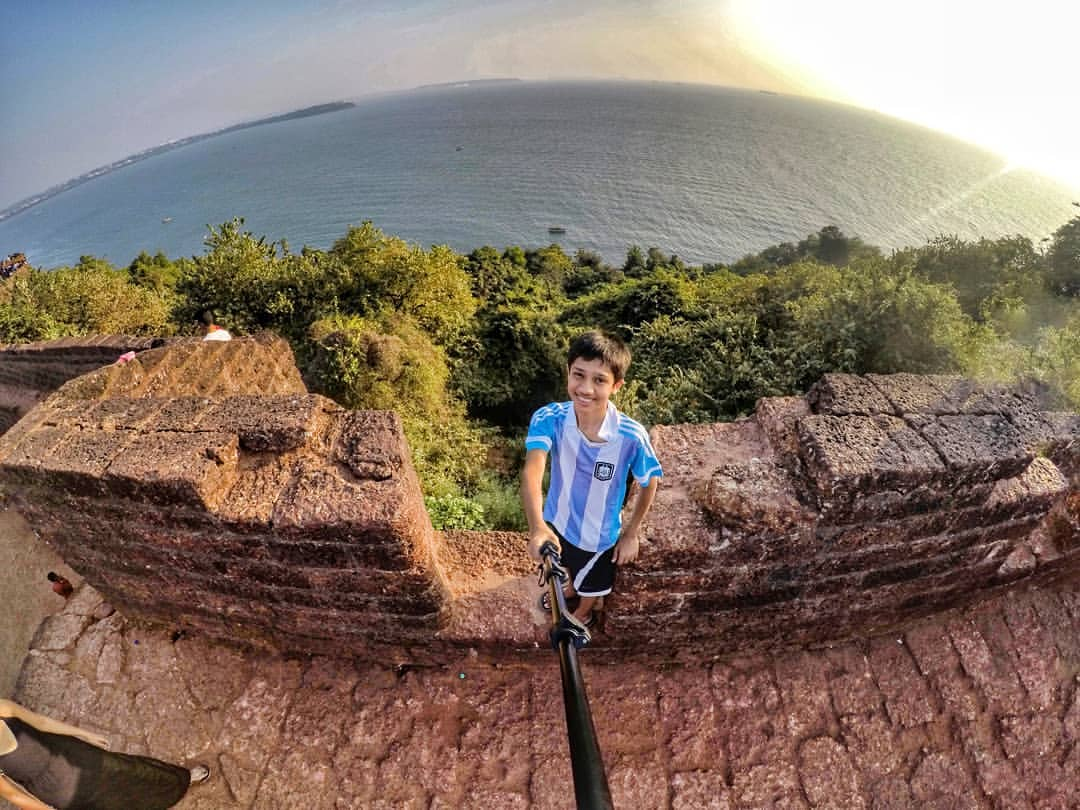

In [84]:
# This is the format:
# instagram-scraper <username we want to scrape> -u <your username> -p <your password>   
! instagram-scraper aagam.b -u aagam.b -p CanthacK1

instagram_username = input('please enter username ')      
listdir = os.listdir(instagram_username)

for image_name in listdir:
    image_path = instagram_username + '/' + image_name
    predictor(image_path)
display(Image(filename = image_path))

## Shows the accuracy of the model

dict_keys(['loss', 'accuracy', 'val_loss', 'val_accuracy'])


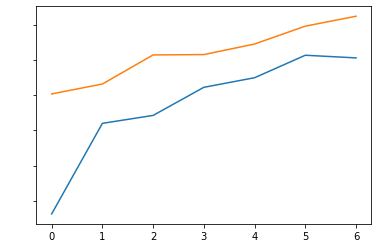

In [104]:
print(final_model.history.keys())

accuracy = final_model.history['accuracy']
val_accuracy = final_model.history['val_accuracy']

plt.figure()
plt.plot(accuracy)
plt.plot(val_accuracy)
# plt.xticks(color = 'white')
# plt.yticks(color = 'white');

# del plt.xticks
